In [3]:
import pandas as pd

df = pd.read_csv("data_black-white.csv")
df.head()

,RACE,MH1,SUB
0,White,Bipolar disorders,-9
1,Black/AA,Schizophrenia or other psychotic disorders,-9
2,White,Schizophrenia or other psychotic disorders,6
3,White,Anxiety disorders,-9
4,Black/AA,Schizophrenia or other psychotic disorders,-9


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 37.6 MB/s  0:00:00 eta 0:00:01


In [6]:
# df = df.drop("SUB", axis=1)
df.head()

,RACE,MH1
0,White,Bipolar disorders
1,Black/AA,Schizophrenia or other psychotic disorders
2,White,Schizophrenia or other psychotic disorders
3,White,Anxiety disorders
4,Black/AA,Schizophrenia or other psychotic disorders


In [9]:
df.to_json("data_black-white.json", orient="records", indent=4)

In [11]:
grouped = df.groupby("RACE").size().reset_index(name="count")

grouped.to_json("grouped.json", orient="records", indent=4)

In [14]:
grouped = df.groupby(["RACE", "MH1"]).size().reset_index(name="count")
grouped

grouped.to_json("grouped.json", orient="records", indent=4)

In [16]:
df = pd.read_json("grouped.json")
df.head()

,RACE,MH1,count
0,Black/AA,ADHD,15143
1,Black/AA,Alcohol or substance use disorders,29538
2,Black/AA,Anxiety disorders,73999
3,Black/AA,Bipolar disorders,96828
4,Black/AA,Conduct disorders,4339


In [21]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 35.7 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 38.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


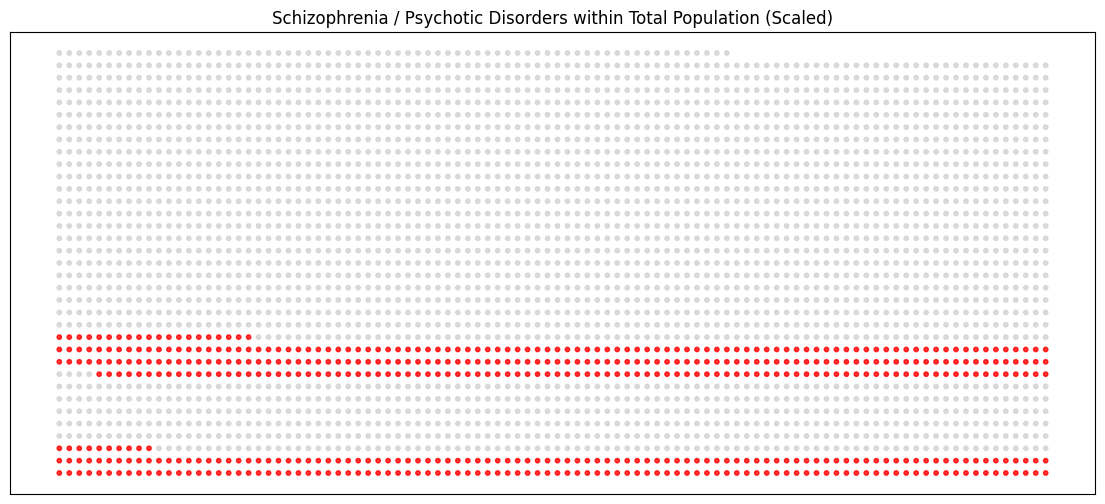

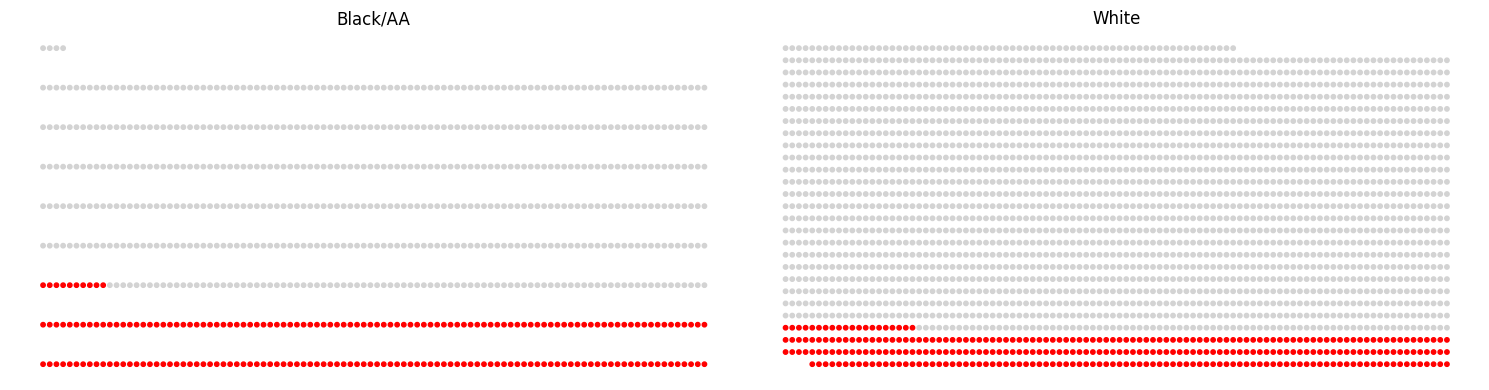

In [23]:
SCALE = 1000

target = "Schizophrenia or other psychotic disorders"

df["is_target"] = df["MH1"] == target

totals = df.groupby("RACE")["count"].sum()
targets = df[df["is_target"]].groupby("RACE")["count"].sum()

targets = targets.reindex(totals.index, fill_value=0)

SCALE = 1000

total_dots = (totals / SCALE).astype(int)
target_dots = (targets / SCALE).astype(int)

dots = []

for race in totals.index:
    total_n = total_dots[race]
    target_n = target_dots[race]

    for i in range(total_n):
        dots.append({
            "race": race,
            "type": "target" if i < target_n else "other"
        })

dots_df = pd.DataFrame(dots)

cols = 100

dots_df["x"] = dots_df.index % cols
dots_df["y"] = dots_df.index // cols

import matplotlib.pyplot as plt

colors = dots_df["type"].map({
    "target": "red",
    "other": "lightgray"
})

plt.figure(figsize=(14, 6))

plt.scatter(
    dots_df["x"],
    dots_df["y"],
    c=colors,
    s=10,
    alpha=0.8
)

plt.title("Schizophrenia / Psychotic Disorders within Total Population (Scaled)")
plt.xticks([])
plt.yticks([])

fig, axes = plt.subplots(1, len(totals.index), figsize=(15, 4))

for ax, race in zip(axes, totals.index):
    subset = dots_df[dots_df["race"] == race]

    ax.scatter(
        subset["x"],
        subset["y"],
        c=subset["type"].map({"target": "red", "other": "lightgray"}),
        s=10
    )

    ax.set_title(race)
    ax.axis("off")

plt.tight_layout()
plt.show()


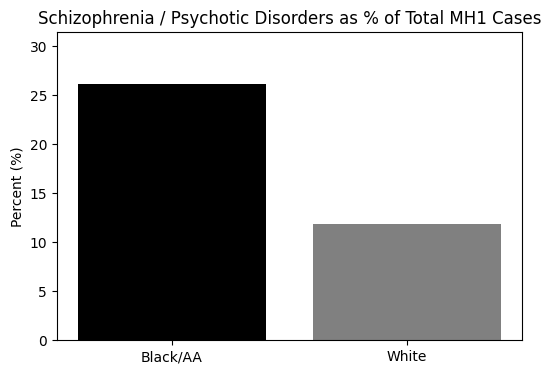

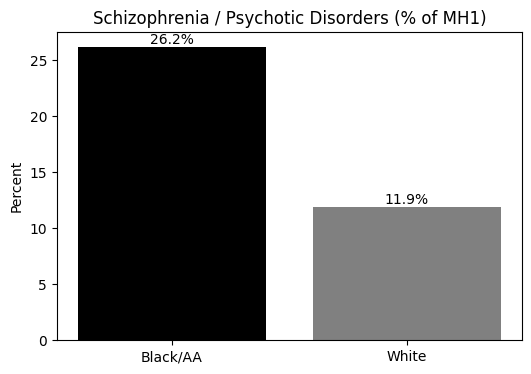

In [26]:
# total per race
race_totals = df.groupby("RACE")["count"].sum()

# schizophrenia subset only
target = "Schizophrenia or other psychotic disorders"
schizo = df[df["MH1"] == target].groupby("RACE")["count"].sum()

# align + fill missing
schizo = schizo.reindex(race_totals.index, fill_value=0)

# percentage
percent = (schizo / race_totals) * 100

percent_df = percent.reset_index()
percent_df.columns = ["RACE", "percent_schizophrenia"]
percent_df

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    percent_df["RACE"],
    percent_df["percent_schizophrenia"],
    color=["black", "gray"]
)

plt.title("Schizophrenia / Psychotic Disorders as % of Total MH1 Cases")
plt.ylabel("Percent (%)")
plt.ylim(0, percent_df["percent_schizophrenia"].max() * 1.2)

plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    percent_df["RACE"],
    percent_df["percent_schizophrenia"],
    color=["black", "gray"]
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Schizophrenia / Psychotic Disorders (% of MH1)")
plt.ylabel("Percent")
plt.show()

plt.show()